In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from utils import Load_img

In [ ]:
GOOD_FOLDER = './data/bottle/test/good'
BRAKE_FOLDER = './data/bottle/test/broken_large'
MODEL_PATH = "./AE.keras"
THRESHOLD = 0.04

In [ ]:
def detect_and_locate_anomaly(original, reconstructed, threshold=0.05):
    # Výpočet MSE pro jednotlivé pixely (přes RGB kanály)
    anomaly_map = tf.reduce_mean(tf.square(original - reconstructed), axis=-1)
    
    # Binární maska: True tam, kde chyba překračuje prahovou hodnotu
    anomaly_mask = anomaly_map > threshold
    
    # Detekce anomálie: True, pokud alespoň jeden pixel překročil práh
    is_anomaly = tf.reduce_any(anomaly_mask)
    
    return anomaly_mask.numpy(), bool(is_anomaly.numpy())

In [ ]:
img_good = Load_img(GOOD_FOLDER)
img_brake = Load_img(BRAKE_FOLDER)
model = tf.keras.models.load_model(MODEL_PATH)

--------------------------------------------------
ANALÝZA OBJEKTU NA DOPRAVNÍKU (Vzorek #20)
STAV: DETEKOVÁN ZMETEK! Komponent byl vyřazen.
--------------------------------------------------


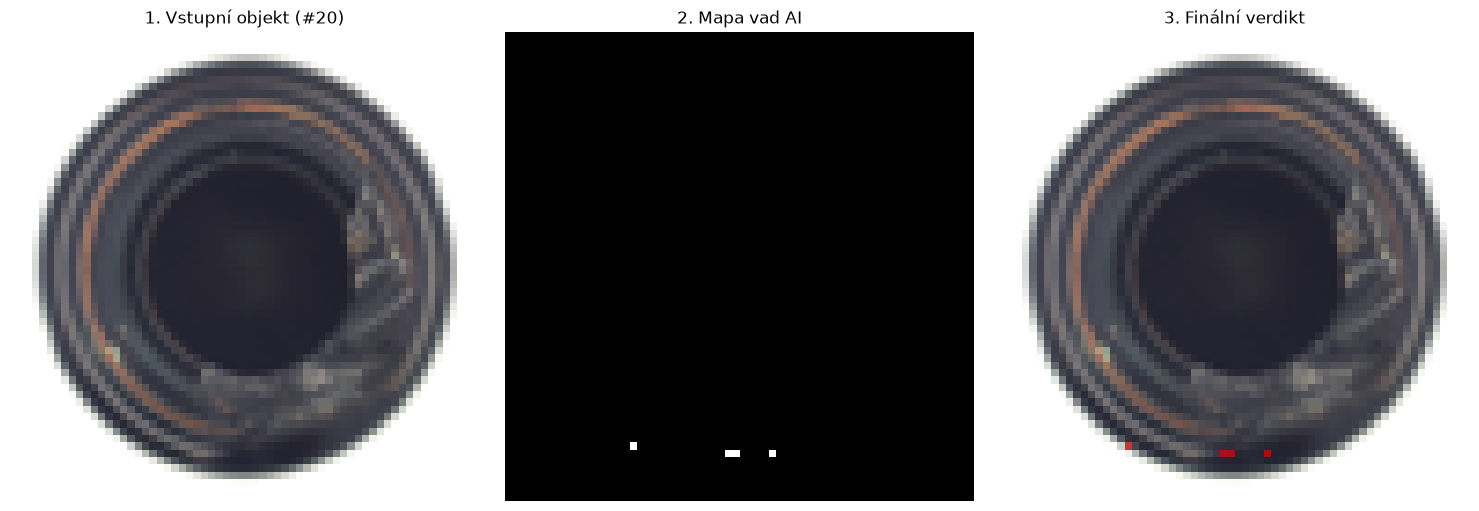

In [24]:
# Společný pool obrázků
all_test_images = np.concatenate([img_good, img_brake], axis=0)

TEST_IDX = 20  

idx = min(TEST_IDX, len(all_test_images) - 1)
input_image = all_test_images[idx]

# Úprava rozměrů na (1, 64, 64, 3) pro model
reconstructed_image = model.predict(input_image[np.newaxis, ...], verbose=0)[0]

mask_pic, has_defect = detect_and_locate_anomaly(input_image, reconstructed_image, threshold=THRESHOLD)

print("-" * 50)
print(f"ANALÝZA OBJEKTU NA DOPRAVNÍKU (Vzorek #{idx})")
if has_defect:
    print("STAV: DETEKOVÁN ZMETEK! Komponent byl vyřazen.")
else:
    print("STAV: KONTROLA OK. Žádné vady nebyly nalezeny.")
print("-" * 50)

# Overlay
red_overlay = np.zeros((64, 64, 4))
if has_defect:
    red_overlay[mask_pic] = [1.0, 0.0, 0.0, 0.6]

# Vykreslení grafů
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(input_image)
axes[0].set_title(f"1. Vstupní objekt (#{idx})")
axes[0].axis("off")

# Bez vady -> černý čtverec
axes[1].imshow(mask_pic, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("2. Mapa vad AI")
axes[1].axis("off")

axes[2].imshow(input_image)
if has_defect:
    axes[2].imshow(red_overlay)
axes[2].set_title("3. Finální verdikt")
axes[2].axis("off")

plt.tight_layout()
plt.show()